<a href="https://colab.research.google.com/github/MrBIue/Le-Minh-Thuan-NLP-NLI-TTNTK46-4654100012/blob/main/nlp_nli_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1 Cài đặt thư viện
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
#2 Tải dữ liệu và chia tỷ lệ 80/10/10 chuẩn Zero-shot
from datasets import load_dataset

print("Đang tải dữ liệu...")
# 1. Tải MultiNLI (Tiếng Anh)
mnli = load_dataset("multi_nli")
# 2. Tải XNLI (Phân vùng Tiếng Việt)
xnli = load_dataset("xnli", "vi")

# --- CHIA TỶ LỆ 80/10/10 ---
# MNLI gốc có gần 400k mẫu, Colab miễn phí sẽ không chạy nổi.
# Ta lấy một tập con (subset) đại diện theo tỷ lệ 16000 : 2000 : 2000

# TRAIN (80%): 16000 mẫu tiếng Anh
train_dataset = mnli["train"].shuffle(seed=42).select(range(16000))

# VALIDATION (10%): 2000 mẫu tiếng Anh (MNLI dùng tên 'validation_matched')
val_dataset = mnli["validation_matched"].shuffle(seed=42).select(range(2000))

# TEST (10%): 2000 mẫu tiếng Việt
test_dataset = xnli["test"].shuffle(seed=42).select(range(2000))

print(f"Số lượng Train (Tiếng Anh): {len(train_dataset)}")
print(f"Số lượng Validation (Tiếng Anh): {len(val_dataset)}")
print(f"Số lượng Test (Tiếng Việt): {len(test_dataset)}")

Đang tải dữ liệu...
Số lượng Train (Tiếng Anh): 16000
Số lượng Validation (Tiếng Anh): 2000
Số lượng Test (Tiếng Việt): 2000


In [ ]:
#3 Tiền xử lý với XLM-RoBERTa
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Khởi tạo mô hình phân loại 3 nhãn (Entailment, Neutral, Contradiction)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

def preprocess_function(examples):
    # XLM-R sẽ tự động chèn token [SEP] giữa premise và hypothesis
    return tokenizer(
        examples["premise"],
        examples["hypothesis"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

print("Đang mã hóa dữ liệu (Tokenization)...")
# Tokenize tập Anh
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
# Tokenize tập Việt
tokenized_test = test_dataset.map(preprocess_function, batched=True)

# Lên danh sách các cột thừa có thể có
potential_cols_mnli = ["promptID", "pairID", "premise", "hypothesis", "premise_binary_parse", "premise_parse", "hypothesis_binary_parse", "hypothesis_parse", "genre"]
potential_cols_xnli = ["premise", "hypothesis", "language"]

# TỰ ĐỘNG LỌC: Chỉ xóa những cột thực sự tồn tại trong dataset hiện tại
cols_to_remove_mnli = [col for col in potential_cols_mnli if col in tokenized_train.column_names]
cols_to_remove_xnli = [col for col in potential_cols_xnli if col in tokenized_test.column_names]

# Thực hiện xóa cột thừa
tokenized_train = tokenized_train.remove_columns(cols_to_remove_mnli)
tokenized_val = tokenized_val.remove_columns(cols_to_remove_mnli)
tokenized_test = tokenized_test.remove_columns(cols_to_remove_xnli)

# Đổi tên cột 'label' thành 'labels' cho đúng chuẩn đầu vào của PyTorch Trainer
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val = tokenized_val.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

print("Tiền xử lý hoàn tất! Các cột hiện tại của tập Test:", tokenized_test.column_names)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đang mã hóa dữ liệu (Tokenization)...


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tiền xử lý hoàn tất! Các cột hiện tại của tập Test: ['labels', 'input_ids', 'attention_mask']


In [ ]:
#4 Thiết lập Huấn luyện
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer

# Hàm tính toán độ chính xác
metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Cấu hình tham số huấn luyện (Đã cập nhật theo API mới nhất)
training_args = TrainingArguments(
    output_dir="./xlmr_nli_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,       # ĐÃ SỬA TẠI ĐÂY: Đổi từ tokenizer thành processing_class
    compute_metrics=compute_metrics
)

# BẮT ĐẦU HUẤN LUYỆN
print("Bắt đầu quá trình Fine-tuning...")
trainer.train()

Bắt đầu quá trình Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.937387,0.869860,0.611500
2,0.691933,0.670869,0.715000
3,0.534714,0.651472,0.747000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3000, training_loss=0.753881113688151, metrics={'train_runtime': 1141.509, 'train_samples_per_second': 42.05, 'train_steps_per_second': 2.628, 'total_flos': 3157361012736000.0, 'train_loss': 0.753881113688151, 'epoch': 3.0})

In [ ]:
#5 Đánh giá Zero-shot trên Tiếng Việt
print("==================================================")
print("BẮT ĐẦU ĐÁNH GIÁ ZERO-SHOT TRÊN TẬP XNLI TIẾNG VIỆT")
print("==================================================")

# Yêu cầu mô hình (chỉ mới học tiếng Anh) làm bài thi tiếng Việt
test_results = trainer.evaluate(eval_dataset=tokenized_test)

print(f"Độ chính xác (Accuracy) trên tiếng Việt: {test_results['eval_accuracy'] * 100:.2f}%")

BẮT ĐẦU ĐÁNH GIÁ ZERO-SHOT TRÊN TẬP XNLI TIẾNG VIỆT


Độ chính xác (Accuracy) trên tiếng Việt: 67.25%


Đang trích xuất dự đoán chi tiết trên tập Test (Tiếng Việt)...



--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
               precision    recall  f1-score   support

   Entailment       0.78      0.54      0.64       660
      Neutral       0.61      0.75      0.67       669
Contradiction       0.67      0.73      0.70       671

     accuracy                           0.67      2000
    macro avg       0.69      0.67      0.67      2000
 weighted avg       0.69      0.67      0.67      2000



Text(0.5, 1.0, 'Ma trận nhầm lẫn trên tập XNLI (Tiếng Việt)')

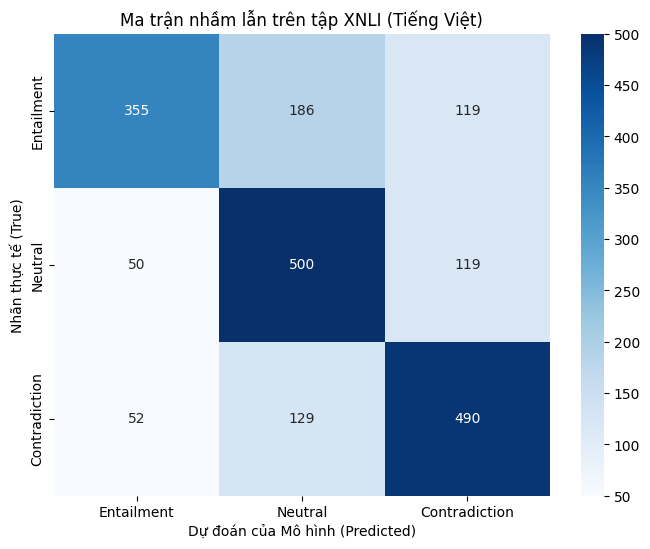

In [ ]:
#6 Vẽ Ma trận nhầm lẫn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Đang trích xuất dự đoán chi tiết trên tập Test (Tiếng Việt)...")
# Lấy dự đoán từ mô hình
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# Tên các nhãn
target_names = ['Entailment', 'Neutral', 'Contradiction']

# 1. In báo cáo F1-Score, Precision, Recall
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
print(classification_report(y_true, y_pred, target_names=target_names))

# 2. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Dự đoán của Mô hình (Predicted)')
plt.ylabel('Nhãn thực tế (True)')
plt.title('Ma trận nhầm lẫn trên tập XNLI (Tiếng Việt)')
#plt.show()